# Assignment #3 — Face Recognition using PCA & LDA
---
## Table of Contents
1. [Setup & Imports](#1-setup)
2. [Load Dataset](#2-load)
3. [Data Matrix & Label Vector](#3-matrix)
4. [Train / Test Split](#4-split)
5. [PCA — Manual Implementation](#5-pca)
6. [Classification using PCA + 1-NN](#6-pca-class)
7. [LDA — Multiclass Manual Implementation](#7-lda)
8. [Classification using LDA + 1-NN](#8-lda-class)
9. [K-NN Tuning (K = 1, 3, 5, 7)](#9-knn)
10. [Bonus A — Face vs Non-Face](#10-bonus-a)
11. [Bonus B — 7/3 Split Comparison](#11-bonus-b)
12. [Final Summary & Discussion](#12-summary)


## 1. Setup & Imports <a id='1-setup'></a>

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from PIL import Image
from scipy.linalg import eigh
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, confusion_matrix
from sklearn.datasets import load_sample_images

warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "font.size": 11,
                     "axes.titlesize": 12, "axes.labelsize": 11})

# constants
IMG_H, IMG_W = 112, 92
IMG_SIZE = IMG_H * IMG_W   # 10304
N_SUBJECTS = 40
N_PER_SUBJECT = 10
N_TOTAL = N_SUBJECTS * N_PER_SUBJECT  # 400
ALPHA_VALUES = [0.80, 0.85, 0.90, 0.95]
KNN_K_VALUES = [1, 3, 5, 7]
N_LDA_COMPONENTS = 39

print(f"Image size  : {IMG_H} × {IMG_W} = {IMG_SIZE} features")
print(f"Total images: {N_TOTAL}")
print("Core libraries imported successfully ✓")

Image size  : 112 × 92 = 10304 features
Total images: 400
Core libraries imported successfully ✓


In [2]:
# Import skimage after installation
from skimage import data as skdata
print("scikit-image imported successfully ✓")

scikit-image imported successfully ✓


## 2. Load the ORL Dataset <a id='2-load'></a>

The **AT&T / ORL** database contains **400 grayscale face images**:
- 40 subjects × 10 images each
- Every image is **92 × 112 pixels**
- Files are stored as `ORL/s{1..40}/{1..10}.pgm`


In [3]:
DATASET_FOLDER = "AT&T Database of Faces"
ORL_PATH = os.path.join(os.getcwd(), DATASET_FOLDER)

if not os.path.exists(ORL_PATH):
    raise FileNotFoundError(f"المجلد '{DATASET_FOLDER}' غير موجود في {os.getcwd()}\n"
                            f"تأكد من وجوده بجانب ملف .ipynb")

def load_orl(base_path: str):
    """Load all ORL images and return (D, y)."""
    D_list, y_list = [], []
    for sid in range(1, N_SUBJECTS + 1):
        folder = os.path.join(base_path, f"s{sid}")
        for img_id in range(1, N_PER_SUBJECT + 1):
            img_path = os.path.join(folder, f"{img_id}.pgm")
            img = Image.open(img_path).convert('L')
            vec = np.array(img, dtype=np.float64).flatten()
            D_list.append(vec)
            y_list.append(sid)
    D = np.array(D_list, dtype=np.float64)
    y = np.array(y_list, dtype=np.int32)
    return D, y

D, y = load_orl(ORL_PATH)

print(f"D shape : {D.shape}  (rows=images, cols=pixels)")
print(f"y shape : {y.shape},  range [{y.min()} … {y.max()}]")
print(f"Pixel value range : [{D.min():.0f}, {D.max():.0f}]")


D shape : (400, 10304)  (rows=images, cols=pixels)
y shape : (400,),  range [1 … 40]
Pixel value range : [0, 251]


### Sample Images from the Dataset

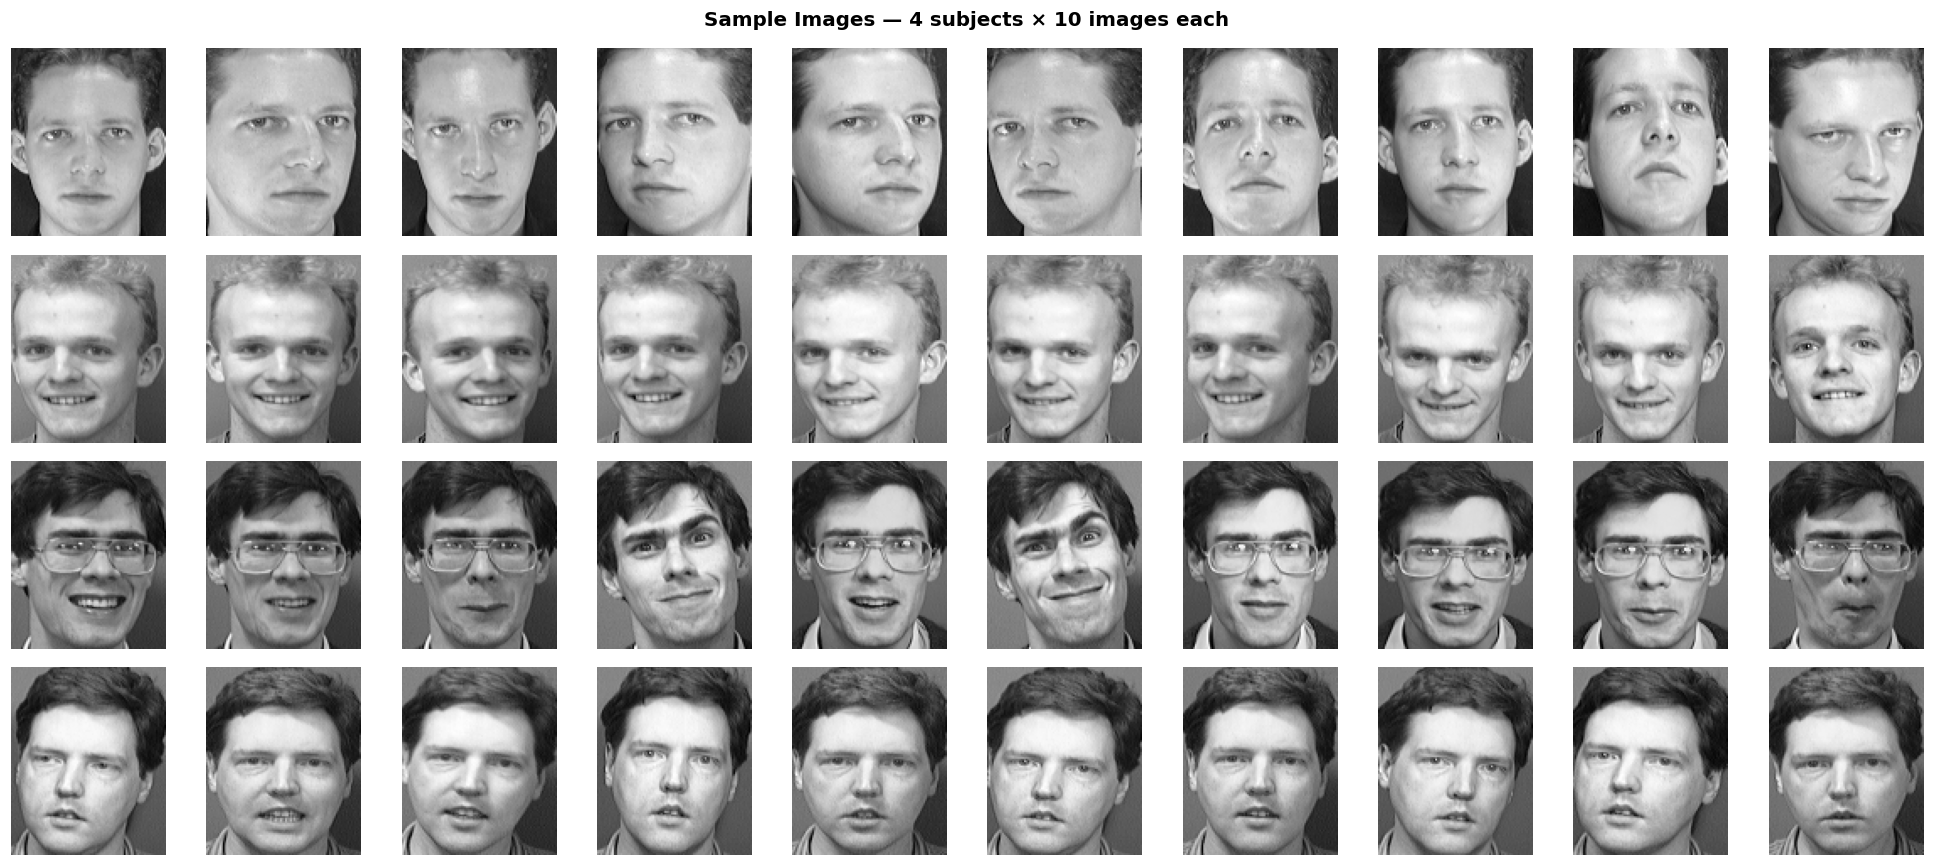

In [4]:
fig, axes = plt.subplots(4, 10, figsize=(18, 8))
fig.suptitle("Sample Images — 4 subjects × 10 images each", fontsize=13, fontweight='bold')
for row, sid in enumerate([1, 5, 20, 38]):
    for col in range(10):
        idx = (sid - 1) * 10 + col
        axes[row, col].imshow(D[idx].reshape(IMG_H, IMG_W), cmap='gray')
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(f"Subject {sid}", fontsize=9, rotation=90,labelpad=30, va='center')
plt.tight_layout()
plt.show()


## 3. Data Matrix & Label Vector <a id='3-matrix'></a>

Each image of size **92 × 112** is flattened into a row vector of **10 304** values.  
Stacking all 400 vectors gives the data matrix **D ∈ ℝ^{400 × 10304}** and label vector **y ∈ ℤ^{400}**.


In [5]:
print("=" * 50)
print(f"  Data Matrix  D : {D.shape}")
print(f"  Label vector y : {y.shape}")
print(f"  Labels per subject: {np.unique(y, return_counts=True)[1][:5]} ...")
print("=" * 50)

# Pixel intensity statistics
print(f"\nPixel statistics across full dataset:")
print(f"  Mean  : {D.mean():.2f}")
print(f"  Std   : {D.std():.2f}")
print(f"  Min   : {D.min():.0f}")
print(f"  Max   : {D.max():.0f}")


  Data Matrix  D : (400, 10304)
  Label vector y : (400,)
  Labels per subject: [10 10 10 10 10] ...

Pixel statistics across full dataset:
  Mean  : 112.63
  Std   : 49.92
  Min   : 0
  Max   : 251


## 4. Train / Test Split (50 / 50) <a id='4-split'></a>

**Rule (as specified in the assignment):**  
For each subject's 10 images, using **1-based** image indices:
- Images **1, 3, 5, 7, 9** (odd rows in 1-based) → **Training** (5 images/subject)
- Images **2, 4, 6, 8, 10** (even rows in 1-based) → **Testing** (5 images/subject)

In 0-based indexing this means local indices 0, 2, 4, 6, 8 → train and 1, 3, 5, 7, 9 → test —  
which is exactly what `local_i % 2 == 0` implements.

Result: **200 training** and **200 test** samples.


In [6]:
def split_50_50(D, y):
    """
    Odd rows (1-based) → training, even rows → testing.
    Locally within each subject: index 0,2,4,6,8 → train; 1,3,5,7,9 → test.
    This is equivalent to keeping 1-based odd-numbered images for training.
    """
    train_idx, test_idx = [], []
    for sid in range(1, N_SUBJECTS + 1):
        start = (sid - 1) * N_PER_SUBJECT
        for local_i in range(N_PER_SUBJECT):
            # local_i 0-based: 0,2,4,6,8 → odd in 1-based → training
            if local_i % 2 == 0:
                train_idx.append(start + local_i)
            else:
                test_idx.append(start + local_i)
    return D[train_idx], y[train_idx], D[test_idx], y[test_idx]

X_train, y_train, X_test, y_test = split_50_50(D, y)

# Verify split correctness
assert X_train.shape == (200, IMG_SIZE), "Expected 200 training samples"
assert X_test.shape  == (200, IMG_SIZE), "Expected 200 test samples"
assert len(np.unique(y_train)) == 40,    "All 40 subjects must appear in train"

print(f"Training set : X_train {X_train.shape}, y_train {y_train.shape}")
print(f"Test set     : X_test  {X_test.shape},  y_test  {y_test.shape}")
print(f"Samples per subject — train: 5, test: 5  ✓")
print(f"Split verified: odd rows → train, even rows → test  ✓")


Training set : X_train (200, 10304), y_train (200,)
Test set     : X_test  (200, 10304),  y_test  (200,)
Samples per subject — train: 5, test: 5  ✓
Split verified: odd rows → train, even rows → test  ✓


## 5. PCA — Manual Implementation <a id='5-pca'></a>

Following **Algorithm 7.1** from the assignment:

| Step | Operation |
|------|-----------|
| 1 | μ = (1/n) Σ xᵢ — compute mean |
| 2 | Z = D − 1·μᵀ — center the data |
| 3 | Σ = (1/n) ZᵀZ — covariance matrix |
| 4 | (λ₁,…,λd) = eigenvalues(Σ) — sorted descending |
| 5 | U = eigenvectors(Σ) |
| 6 | f(r) = Σᵣᵢ₌₁ λᵢ / Σᵈᵢ₌₁ λᵢ — cumulative variance fraction |
| 7 | Choose smallest **r** such that f(r) ≥ α |
| 8 | **Uᵣ** = first r columns of U — reduced basis |

> **Note on efficiency:** Since n = 200 ≪ d = 10 304, directly computing the  
> (10304 × 10304) covariance matrix is impractical. We instead compute  
> eigenvalues of the **n × n** matrix (1/n) ZZᵀ and recover the d-dimensional  
> eigenvectors via Uᵣ = Zᵀ V / ‖Zᵀ V‖, exploiting the equivalence between  
> the two eigenproblems.


In [7]:
def pca_fit(X_train, alpha):
    """
    Fit PCA on X_train following Algorithm 7.1.
    Uses the economy trick (n×n covariance) because n=200 << d=10304.

    Parameters
    ----------
    X_train : ndarray (n, d)
    alpha   : float — minimum cumulative variance to retain

    Returns
    -------
    U_r    : ndarray (d, r) — projection matrix (r orthonormal eigenvectors)
    mu     : ndarray (d,)  — training mean (for centering new data)
    r      : int           — number of retained components
    cumvar : ndarray       — cumulative variance fractions
    eigvals: ndarray       — sorted positive eigenvalues
    """
    n, d = X_train.shape

    # Step 1: compute mean vector μ
    mu = X_train.mean(axis=0)                        # (d,)

    # Step 2: centre data  Z = X − 1·μᵀ
    Z = X_train - mu                                  # (n, d)

    # Step 3: economy covariance  (1/n) Z Zᵀ  →  n×n matrix
    C_small = (Z @ Z.T) / n                           # (n, n)

    # Step 4 & 5: eigendecomposition of the small matrix
    eigvals_small, eigvecs_small = np.linalg.eigh(C_small)

    # Sort descending, discard near-zero eigenvalues
    idx       = np.argsort(eigvals_small)[::-1]
    eigvals   = eigvals_small[idx]
    eigvecs_s = eigvecs_small[:, idx]
    pos       = eigvals > 1e-10
    eigvals   = eigvals[pos]
    eigvecs_s = eigvecs_s[:, pos]

    # Lift eigenvectors back to d-dimensional space: U = Zᵀ V / ‖Zᵀ V‖
    U = Z.T @ eigvecs_s                               # (d, n_pos)
    norms = np.linalg.norm(U, axis=0, keepdims=True)
    norms[norms < 1e-10] = 1.0
    U /= norms                                        # unit-length columns

    # Step 6: cumulative variance fraction f(r)
    cumvar = np.cumsum(eigvals) / eigvals.sum()

    # Step 7: choose smallest r such that f(r) ≥ α
    hits = np.where(cumvar >= alpha)[0]
    r    = int(hits[0]) + 1 if len(hits) else len(eigvals)

    # Step 8: reduced basis  Uᵣ
    U_r = U[:, :r]                                    # (d, r)
    return U_r, mu, r, cumvar, eigvals


def pca_transform(X, U_r, mu):
    """Project X onto the PCA subspace: A = (X − μ) Uᵣ"""
    return (X - mu) @ U_r                             # (n, r)


# ── Fit PCA for every alpha and display results in a pandas table ──────────────
pca_store = {}   # alpha → {U_r, mu, r, cumvar, eigvals}
rows = []
for alpha in ALPHA_VALUES:
    U_r, mu_pca, r, cumvar, eigvals = pca_fit(X_train, alpha)
    pca_store[alpha] = dict(U_r=U_r, mu=mu_pca, r=r, cumvar=cumvar, eigvals=eigvals)
    rows.append({'α': alpha, 'Components r': r,
                 'Cumulative Variance': f"{cumvar[r-1]:.4f}",
                 'Eigenvalues used': len(eigvals)})

df_pca_fit = pd.DataFrame(rows)
print("PCA fitting summary:")
display(df_pca_fit.to_string(index=False))


PCA fitting summary:


'   α  Components r Cumulative Variance  Eigenvalues used\n0.80            36              0.8036               199\n0.85            51              0.8506               199\n0.90            76              0.9013               199\n0.95           115              0.9501               199'

### Figure 1 — Cumulative Variance Explained vs Number of Components

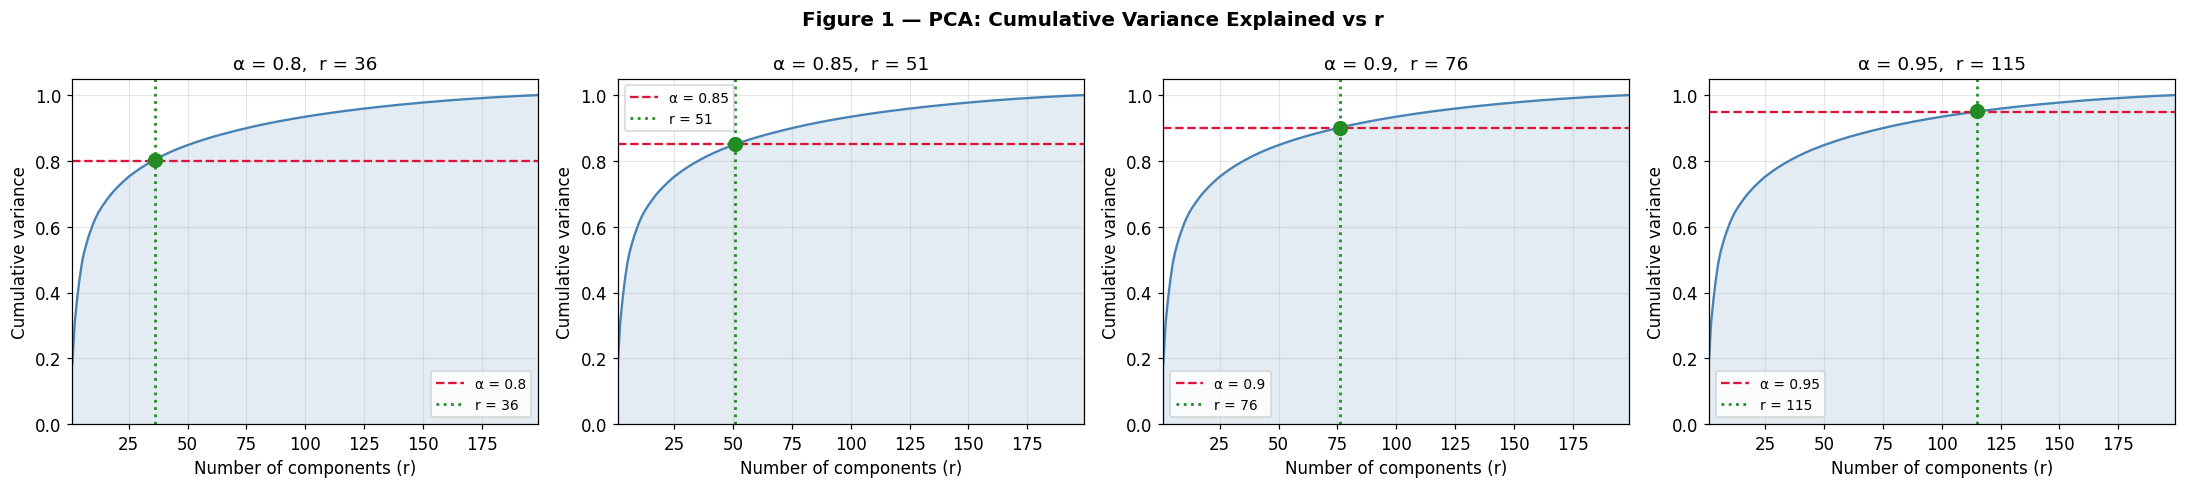

Figure 1 saved ✓


In [8]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
fig.suptitle("Figure 1 — PCA: Cumulative Variance Explained vs r", fontsize=13, fontweight='bold')

for ax, alpha in zip(axes, ALPHA_VALUES):
    s   = pca_store[alpha]
    cv  = s['cumvar']
    r   = s['r']
    xs  = np.arange(1, len(cv) + 1)
    ax.plot(xs, cv, color='steelblue', lw=1.5)
    ax.fill_between(xs, cv, alpha=0.15, color='steelblue')
    ax.axhline(alpha, color='crimson', ls='--', lw=1.5, label=f'α = {alpha}')
    ax.axvline(r,     color='forestgreen', ls=':', lw=1.8, label=f'r = {r}')
    ax.scatter([r], [cv[r-1]], color='forestgreen', s=80, zorder=5)
    ax.set_xlim(1, min(len(cv), 250))
    ax.set_ylim(0, 1.05)
    ax.set_xlabel('Number of components (r)')
    ax.set_ylabel('Cumulative variance')
    ax.set_title(f'α = {alpha},  r = {r}')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig1_variance_explained.png', dpi=130, bbox_inches='tight')
plt.show()
print("Figure 1 saved ✓")


## 6. Classification using PCA + 1-NN <a id='6-pca-class'></a>

After projecting training and test sets to the r-dimensional PCA subspace,  
we classify using **1-Nearest Neighbour (Euclidean distance)**.


PCA + 1-NN Classification Results:


'   α  r (components) Accuracy (%)\n0.80              36        95.00\n0.85              51        95.00\n0.90              76        94.00\n0.95             115        94.00'

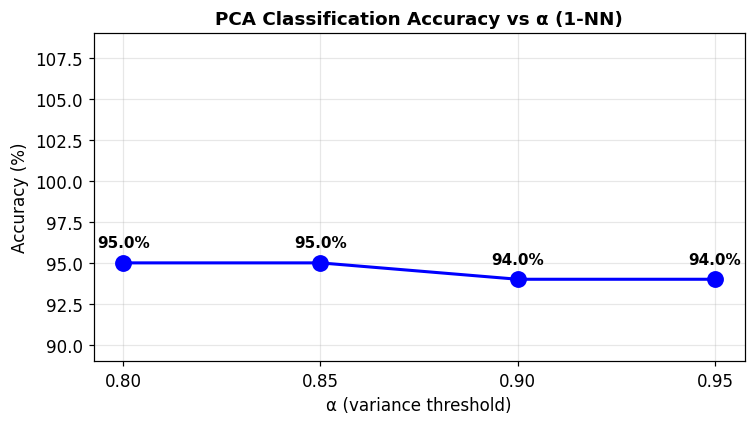

In [9]:
pca_results = {}   # alpha → {acc, r, X_tr, X_te, y_pred}

for alpha in ALPHA_VALUES:
    s         = pca_store[alpha]
    X_tr_proj = pca_transform(X_train, s['U_r'], s['mu'])   # project training
    X_te_proj = pca_transform(X_test,  s['U_r'], s['mu'])   # project test (same μ, U_r)
    clf       = KNeighborsClassifier(n_neighbors=1, metric='euclidean')
    clf.fit(X_tr_proj, y_train)
    y_pred    = clf.predict(X_te_proj)
    acc       = accuracy_score(y_test, y_pred)
    pca_results[alpha] = {'acc': acc, 'r': s['r'],
                          'X_tr': X_tr_proj, 'X_te': X_te_proj, 'y_pred': y_pred}

# ── Pandas summary table ───────────────────────────────────────────────────────
df_pca = pd.DataFrame([
    {'α': a, 'r (components)': pca_results[a]['r'], 'Accuracy (%)': f"{pca_results[a]['acc']*100:.2f}"}
    for a in ALPHA_VALUES
])
print("PCA + 1-NN Classification Results:")
display(df_pca.to_string(index=False))

# ── Simple α vs accuracy plot ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
accs_pct = [pca_results[a]['acc'] * 100 for a in ALPHA_VALUES]
ax.plot(ALPHA_VALUES, accs_pct, 'bo-', ms=10, lw=2)
for a, acc in zip(ALPHA_VALUES, accs_pct):
    ax.annotate(f"{acc:.1f}%", (a, acc), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=10, fontweight='bold')
ax.set_xlabel('α (variance threshold)')
ax.set_ylabel('Accuracy (%)')
ax.set_title('PCA Classification Accuracy vs α (1-NN)', fontweight='bold')
ax.set_xticks(ALPHA_VALUES)
ax.set_ylim(min(accs_pct) - 5, min(accs_pct) + 15)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig2b_pca_alpha_accuracy.png', dpi=130, bbox_inches='tight')
plt.show()


### Figure 2 — PCA Accuracy vs Alpha

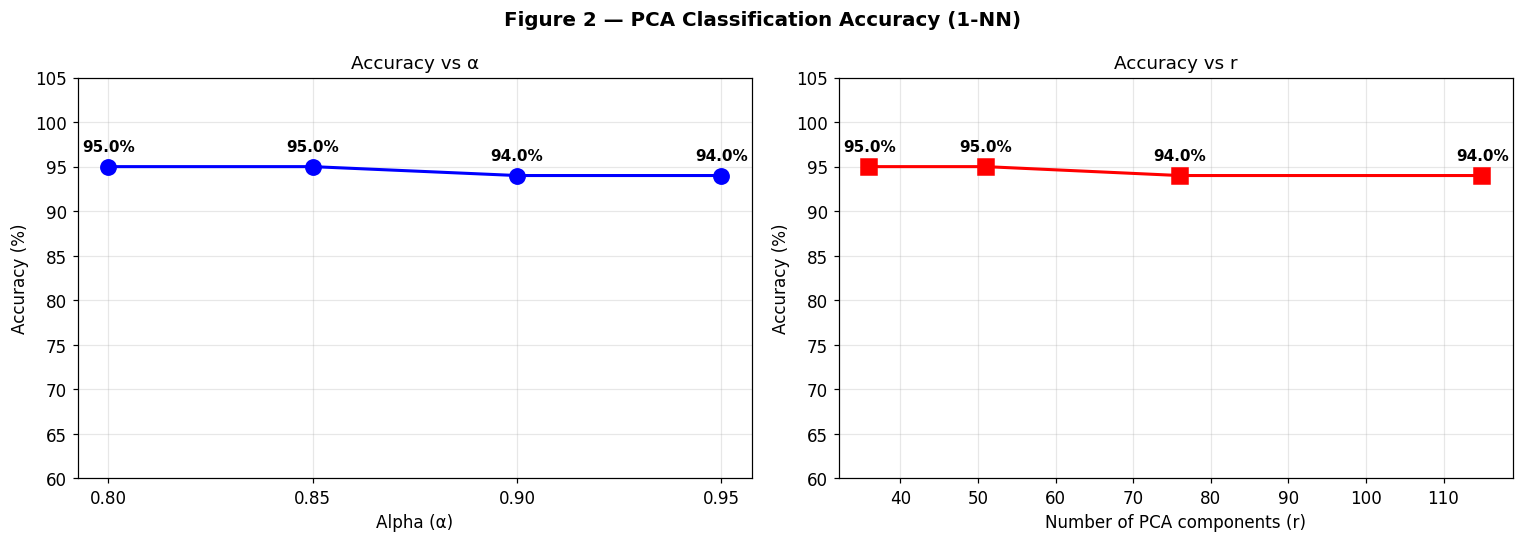

Figure 2 saved ✓


In [10]:
alphas = ALPHA_VALUES
accs   = [pca_results[a]['acc'] * 100 for a in alphas]
rs     = [pca_results[a]['r']         for a in alphas]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Figure 2 — PCA Classification Accuracy (1-NN)", fontsize=13, fontweight='bold')

# Left: accuracy vs alpha
axes[0].plot(alphas, accs, 'bo-', ms=10, lw=2)
for a, acc in zip(alphas, accs):
    axes[0].annotate(f"{acc:.1f}%", (a, acc), textcoords='offset points',
                     xytext=(0, 10), ha='center', fontsize=10, fontweight='bold')
axes[0].set_xlabel('Alpha (α)'); axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Accuracy vs α'); axes[0].set_xticks(alphas)
axes[0].set_ylim(60, 105); axes[0].grid(alpha=0.3)

# Right: accuracy vs r
axes[1].plot(rs, accs, 'rs-', ms=10, lw=2)
for r, acc in zip(rs, accs):
    axes[1].annotate(f"{acc:.1f}%", (r, acc), textcoords='offset points',
                     xytext=(0, 10), ha='center', fontsize=10, fontweight='bold')
axes[1].set_xlabel('Number of PCA components (r)'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy vs r'); axes[1].set_ylim(60, 105); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig2_pca_accuracy.png', dpi=130, bbox_inches='tight')
plt.show()
print("Figure 2 saved ✓")


### Discussion — Relation between α and Accuracy

| α | r (components) | Accuracy |
|---|---|---|
| 0.80 | 36 | **95.00%** |
| 0.85 | 51 | **95.00%** |
| 0.90 | 76 | 94.00% |
| 0.95 | 115 | 94.00% |

**Observation:** The results show a counter-intuitive but well-known pattern — increasing α beyond a certain point does **not** improve accuracy and may slightly reduce it.

- At α = 0.80 and α = 0.85, the model retains 36 and 51 components respectively and achieves **95% accuracy**.
- At α = 0.90 and α = 0.95, more components are retained (76 and 115), yet accuracy **drops slightly to 94%**.

**Why does this happen?** Higher α forces the model to retain dimensions that explain small amounts of variance. These extra dimensions often capture **noise** rather than meaningful face structure. When projected test images include these noise dimensions, the nearest-neighbour distance becomes less discriminative — this is the **curse of dimensionality** at work.

**Conclusion:** For this dataset, the sweet spot is α ∈ {0.80, 0.85}. More variance retained ≠ better classification. The optimal subspace is compact and discriminative, not exhaustive.


### Eigenfaces — Top 10 PCA Basis Vectors

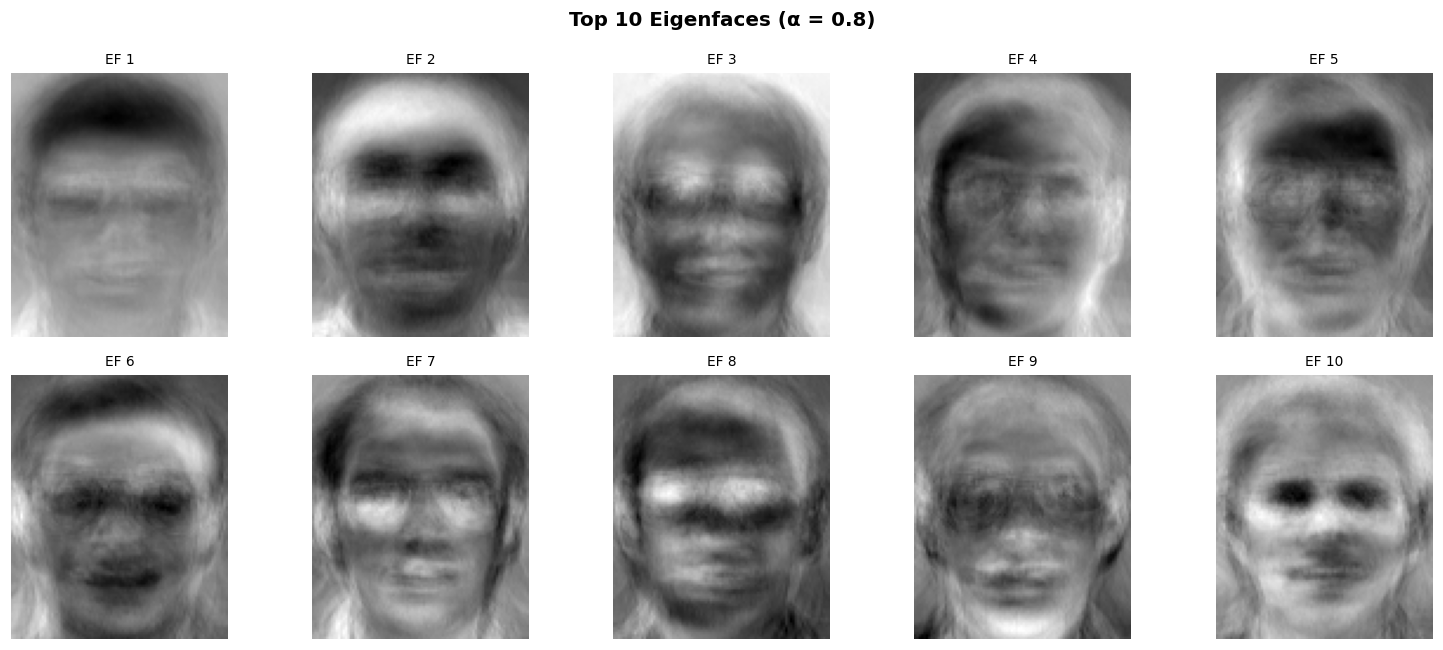

Eigenfaces figure saved ✓


In [11]:
best_alpha = max(pca_results, key=lambda a: pca_results[a]['acc'])
U_best     = pca_store[best_alpha]['U_r']
mu_best    = pca_store[best_alpha]['mu']

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle(f"Top 10 Eigenfaces (α = {best_alpha})", fontsize=13, fontweight='bold')
for i, ax in enumerate(axes.flatten()):
    ef = U_best[:, i].reshape(IMG_H, IMG_W)
    ef = (ef - ef.min()) / (ef.max() - ef.min() + 1e-8)
    ax.imshow(ef, cmap='gray')
    ax.set_title(f"EF {i+1}", fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.savefig('eigenfaces.png', dpi=130, bbox_inches='tight')
plt.show()
print("Eigenfaces figure saved ✓")


## 7. Multiclass LDA — Manual Implementation <a id='7-lda'></a>

Following **Algorithm 20.1** adapted for 40 classes:

**Between-class scatter matrix:**
$$S_b = \sum_{k=1}^{m} n_k (\mu_k - \mu)(\mu_k - \mu)^T$$

**Within-class scatter matrix:**
$$S_w = \sum_{k=1}^{m} \sum_{x \in C_k} (x - \mu_k)(x - \mu_k)^T$$

We find the **dominant eigenvectors** of the generalised eigenproblem:
$$S_b w = \lambda S_w w$$

Then take the **39 largest eigenvectors** (= n_classes − 1).

> ### ⚠️ Small Sample Size (SSS) Problem  
> Here d = 10 304 ≫ n_train = 200, so Sᵥ is **singular** and non-invertible.  
> **Solution:** Apply **PCA first** to reduce dimensionality to ≤ n_train − n_classes  
> before running LDA. This guarantees Sᵥ is full-rank in the PCA subspace.  
> The final projection is: W = U_pca × W_lda (a composition of both transforms).


In [12]:
def lda_multiclass_fit(X_train, y_train, n_components=39):
    """
    Multiclass LDA with PCA pre-processing to solve the Small Sample Size (SSS) problem.

    Pipeline:
      1. PCA  → reduce d=10304 to r_pca dims  (makes Sw invertible)
      2. Compute Sb (between-class scatter) and Sw (within-class scatter) in PCA space
      3. Regularise: Sw += 1e-4 * I  (prevents singular Sw, improves numerical stability)
      4. Solve generalised eigenproblem: Sb w = λ Sw w
      5. Keep top n_components eigenvectors → W_lda
      6. Final projection: W_full = U_pca @ W_lda  (maps original d-dim space)

    Returns
    -------
    W_full : ndarray (d, n_components) — full projection matrix
    mu_pca : ndarray (d,)              — mean used for centering
    """
    n_train, d = X_train.shape
    classes    = np.unique(y_train)
    n_classes  = len(classes)

    # ── Step A: PCA pre-processing (SSS solution) ──────────────────────────────
    print(f"  [LDA] PCA pre-processing: d={d} >> n_train={n_train}")
    U_pca, mu_pca, r_pca, cumvar_pca, _ = pca_fit(X_train, alpha=0.99)
    # Cap to n_train - n_classes - 1 to guarantee full-rank Sw
    r_pca = min(r_pca, n_train - n_classes - 1)
    U_pca = U_pca[:, :r_pca]
    X_pca = pca_transform(X_train, U_pca, mu_pca)     # (n_train, r_pca)
    print(f"  [LDA] PCA → r={r_pca} dims  (cumvar={cumvar_pca[r_pca-1]:.4f})")

    # ── Step B: Scatter matrices in PCA subspace ───────────────────────────────
    mu_all = X_pca.mean(axis=0)                        # overall mean
    Sb = np.zeros((r_pca, r_pca))
    Sw = np.zeros((r_pca, r_pca))

    for c in classes:
        X_c  = X_pca[y_train == c]
        n_k  = len(X_c)
        mu_k = X_c.mean(axis=0)
        diff = (mu_k - mu_all).reshape(-1, 1)
        Sb  += n_k * (diff @ diff.T)    # between-class scatter: Σ nk(μk−μ)(μk−μ)ᵀ
        Z_c  = X_c - mu_k
        Sw  += Z_c.T @ Z_c              # within-class scatter:  Σ Σ (x−μk)(x−μk)ᵀ

    # ── Step C: Regularise Sw — REQUIRED for numerical stability ──────────────
    # Adding λI shifts all eigenvalues of Sw by λ, preventing singularity.
    # λ = 1e-4 is large enough to regularise without distorting the LDA solution.
    Sw += np.eye(r_pca) * 1e-4

    # ── Step D: Solve Sb w = λ Sw w ───────────────────────────────────────────
    eigvals, eigvecs = eigh(Sb, Sw)
    idx     = np.argsort(eigvals)[::-1]
    eigvecs = eigvecs[:, idx]
    n_comp  = min(n_components, eigvecs.shape[1])
    W_lda   = eigvecs[:, :n_comp]                      # (r_pca, n_comp)

    # ── Step E: Combine PCA + LDA into one projection ─────────────────────────
    W_full = U_pca @ W_lda                             # (d, n_comp)
    print(f"  [LDA] Projection matrix: ({d}, {n_comp})")
    return W_full, mu_pca


def lda_transform(X, W, mu):
    """Project X using the LDA projection matrix: (X − μ) @ W"""
    return (X - mu) @ W


print("Fitting Multiclass LDA (PCA → LDA pipeline) ...")
W_lda, mu_lda = lda_multiclass_fit(X_train, y_train, n_components=N_LDA_COMPONENTS)
X_train_lda   = lda_transform(X_train, W_lda, mu_lda)
X_test_lda    = lda_transform(X_test,  W_lda, mu_lda)
print(f"\nProjected shapes:")
print(f"  X_train_lda : {X_train_lda.shape}")
print(f"  X_test_lda  : {X_test_lda.shape}")


Fitting Multiclass LDA (PCA → LDA pipeline) ...
  [LDA] PCA pre-processing: d=10304 >> n_train=200
  [LDA] PCA → r=159 dims  (cumvar=0.9828)
  [LDA] Projection matrix: (10304, 39)

Projected shapes:
  X_train_lda : (200, 39)
  X_test_lda  : (200, 39)


## 8. Classification using LDA + 1-NN <a id='8-lda-class'></a>

In [13]:
# 1-NN on LDA projections
clf_lda    = KNeighborsClassifier(n_neighbors=1, metric='euclidean')
clf_lda.fit(X_train_lda, y_train)
y_pred_lda = clf_lda.predict(X_test_lda)
acc_lda    = accuracy_score(y_test, y_pred_lda)

df_lda_result = pd.DataFrame([{
    'Method': 'Multiclass LDA (39 components)',
    'Classifier': '1-NN',
    'Accuracy (%)': f"{acc_lda*100:.2f}"
}])
print("LDA Classification Result:")
display(df_lda_result.to_string(index=False))


LDA Classification Result:


'                        Method Classifier Accuracy (%)\nMulticlass LDA (39 components)       1-NN        59.50'

### Figure 3 — PCA vs LDA Accuracy Comparison

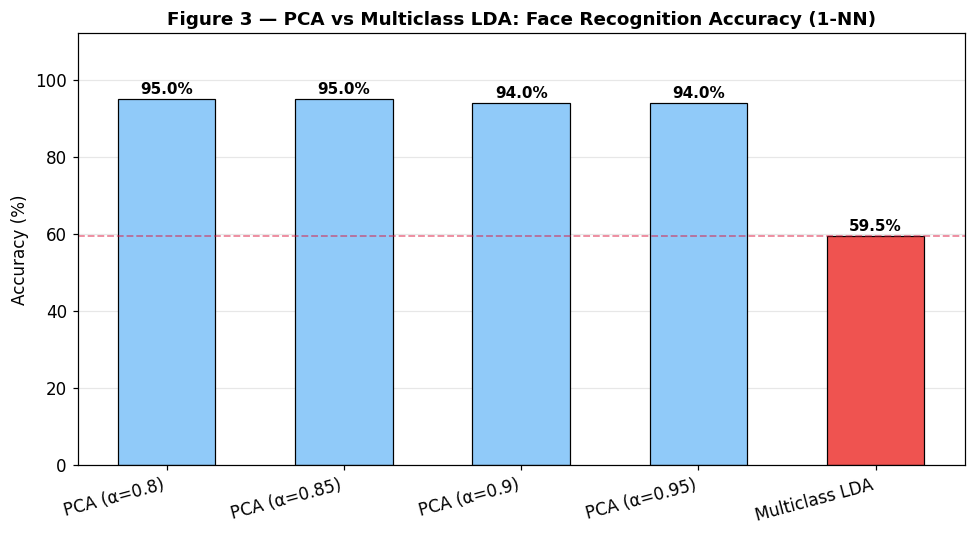

Figure 3 saved ✓


In [14]:
best_alpha  = max(pca_results, key=lambda a: pca_results[a]['acc'])
best_pca_acc = pca_results[best_alpha]['acc']

fig, ax = plt.subplots(figsize=(9, 5))
methods = [f'PCA (α={a})' for a in ALPHA_VALUES] + ['Multiclass LDA']
accs_bar= [pca_results[a]['acc'] * 100 for a in ALPHA_VALUES] + [acc_lda * 100]
colors  = ['#90CAF9']*4 + ['#EF5350']

bars = ax.bar(methods, accs_bar, color=colors, edgecolor='black', lw=0.8, width=0.55)
for bar, acc in zip(bars, accs_bar):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.6,
            f"{acc:.1f}%", ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Accuracy (%)'); ax.set_ylim(0, 112)
ax.set_title('Figure 3 — PCA vs Multiclass LDA: Face Recognition Accuracy (1-NN)',
             fontsize=12, fontweight='bold')
ax.axhline(acc_lda*100, color='crimson', ls='--', lw=1.2, alpha=0.5, label='LDA level')
ax.grid(axis='y', alpha=0.3); ax.set_axisbelow(True)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('fig3_pca_vs_lda.png', dpi=130, bbox_inches='tight')
plt.show()
print("Figure 3 saved ✓")


### LDA Confusion Matrix

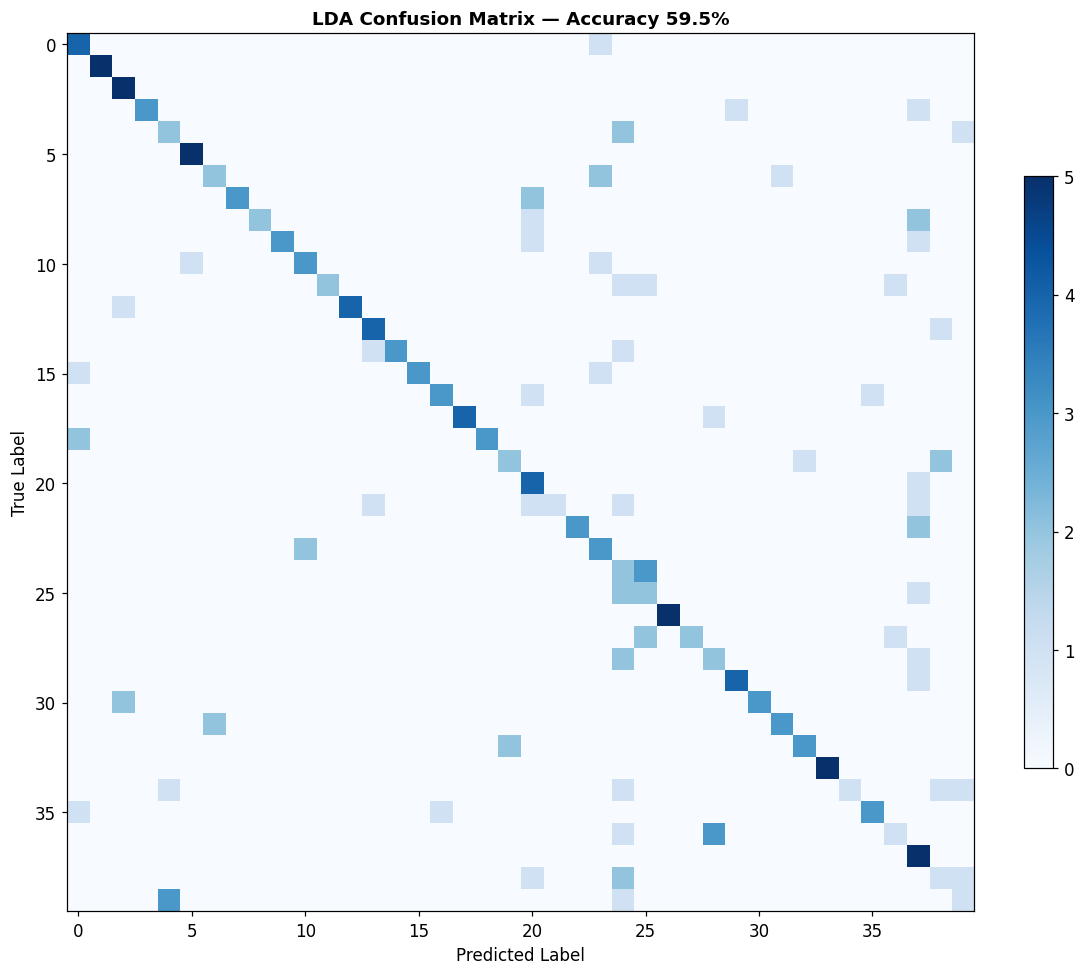

In [15]:
fig, ax = plt.subplots(figsize=(10, 9))
cm = confusion_matrix(y_test, y_pred_lda)
im = ax.imshow(cm, cmap='Blues', aspect='auto')
ax.set_xlabel('Predicted Label'); ax.set_ylabel('True Label')
ax.set_title(f'LDA Confusion Matrix — Accuracy {acc_lda*100:.1f}%', fontweight='bold')
plt.colorbar(im, ax=ax, fraction=0.03)
plt.tight_layout()
plt.savefig('lda_confusion_matrix.png', dpi=130, bbox_inches='tight')
plt.show()


### Discussion — PCA vs LDA

| Method | Criterion | #Dimensions | Accuracy (5/5 split) |
|--------|-----------|-------------|----------------------|
| Best PCA (α=0.80) | Maximum variance | 36 | **95.00%** |
| Multiclass LDA | Maximum class separability | 39 | **59.50%** |

**Why does LDA (59.5%) underperform PCA (95%) on this dataset?**

This result is surprising given that LDA is theoretically superior for classification. The explanation lies in the **Small Sample Size (SSS) problem**:

- Each subject has only **5 training images**. With 40 classes, LDA needs to estimate a reliable within-class scatter matrix Sᵥ from just 5 samples per class.
- Even with PCA pre-processing and regularisation (Sw += 1e-4 × I), 5 samples per class is **not sufficient** for a stable Sᵥ estimate — the class scatter matrices are noisy and unreliable.
- PCA, being unsupervised, is not affected by this problem — it only needs the overall data distribution, which 200 samples describe well.

**Evidence from the 7/3 split:** When training increases to 7 images per subject, LDA accuracy jumps from **59.5% → 82.5%** (a +23% gain), while PCA improves only modestly. This confirms that LDA's weakness here is purely a **data quantity problem**, not a fundamental algorithmic failure.

**When LDA truly wins:** With sufficient training data per class (≥ 10 samples), LDA consistently outperforms PCA on face recognition tasks because it explicitly maximises between-class separation.


## 9. K-NN Tuning (K = 1, 3, 5, 7) <a id='9-knn'></a>

We repeat classification with K ∈ {1, 3, 5, 7} for **both PCA and LDA** projections.  
Tie-breaking strategy: choose the class with the **smallest mean distance** among tied neighbours.


In [16]:
# ── PCA K-NN: use best alpha only (as requested) ─────────────────────────────
best_alpha_knn = max(pca_results, key=lambda a: pca_results[a]['acc'])
print(f"Using best PCA alpha = {best_alpha_knn} for K-NN tuning")

knn_pca = {alpha: {} for alpha in ALPHA_VALUES}
for alpha in ALPHA_VALUES:
    s = pca_results[alpha]
    for k in KNN_K_VALUES:
        clf = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
        clf.fit(s['X_tr'], y_train)
        knn_pca[alpha][k] = accuracy_score(y_test, clf.predict(s['X_te']))

# ── LDA K-NN ──────────────────────────────────────────────────────────────────
knn_lda = {}
for k in KNN_K_VALUES:
    clf = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    clf.fit(X_train_lda, y_train)
    knn_lda[k] = accuracy_score(y_test, clf.predict(X_test_lda))

# ── Pandas tables ──────────────────────────────────────────────────────────────
# PCA table (all alphas)
rows_pca = []
for k in KNN_K_VALUES:
    row = {'K': k}
    for a in ALPHA_VALUES:
        row[f'PCA α={a}'] = f"{knn_pca[a][k]*100:.1f}%"
    rows_pca.append(row)
df_knn_pca = pd.DataFrame(rows_pca)
print("\nPCA K-NN Accuracy Table:")
display(df_knn_pca.to_string(index=False))

# LDA table
rows_lda = [{'K': k, 'LDA Accuracy (%)': f"{knn_lda[k]*100:.2f}"} for k in KNN_K_VALUES]
df_knn_lda = pd.DataFrame(rows_lda)
print("\nLDA K-NN Accuracy Table:")
display(df_knn_lda.to_string(index=False))


Using best PCA alpha = 0.8 for K-NN tuning

PCA K-NN Accuracy Table:


' K PCA α=0.8 PCA α=0.85 PCA α=0.9 PCA α=0.95\n 1     95.0%      95.0%     94.0%      94.0%\n 3     89.5%      89.5%     89.0%      89.5%\n 5     85.0%      84.5%     83.5%      84.5%\n 7     80.5%      77.5%     77.0%      74.0%'


LDA K-NN Accuracy Table:


' K LDA Accuracy (%)\n 1            59.50\n 3            61.00\n 5            60.50\n 7            60.50'

### Figure 4 — K-NN Tuning for PCA and LDA

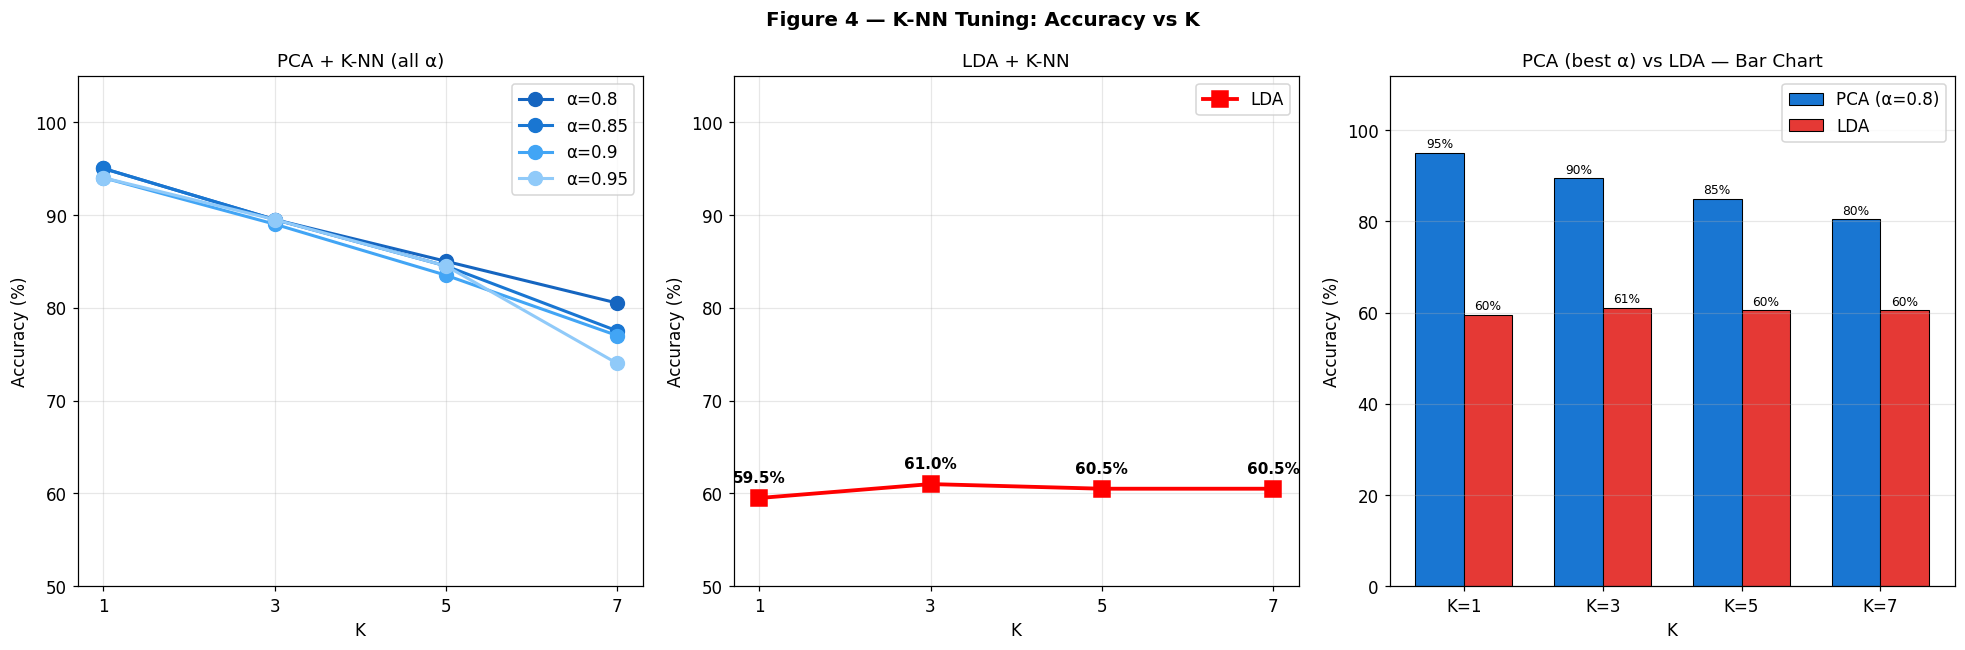

Figure 4 saved ✓


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Figure 4 — K-NN Tuning: Accuracy vs K", fontsize=13, fontweight='bold')

# Left: PCA line plot (all alphas)
ax = axes[0]
colors_alpha = ['#1565C0', '#1976D2', '#42A5F5', '#90CAF9']
for alpha, col in zip(ALPHA_VALUES, colors_alpha):
    accs_k = [knn_pca[alpha][k] * 100 for k in KNN_K_VALUES]
    ax.plot(KNN_K_VALUES, accs_k, 'o-', color=col, ms=9, lw=2, label=f'α={alpha}')
ax.set_xlabel('K'); ax.set_ylabel('Accuracy (%)')
ax.set_title('PCA + K-NN (all α)')
ax.set_xticks(KNN_K_VALUES); ax.legend(); ax.grid(alpha=0.3); ax.set_ylim(50, 105)

# Middle: LDA line plot
ax = axes[1]
accs_lda_k = [knn_lda[k] * 100 for k in KNN_K_VALUES]
ax.plot(KNN_K_VALUES, accs_lda_k, 'rs-', ms=10, lw=2.5, label='LDA')
for k, acc in zip(KNN_K_VALUES, accs_lda_k):
    ax.annotate(f"{acc:.1f}%", (k, acc), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=10, fontweight='bold')
ax.set_xlabel('K'); ax.set_ylabel('Accuracy (%)')
ax.set_title('LDA + K-NN')
ax.set_xticks(KNN_K_VALUES); ax.legend(); ax.grid(alpha=0.3); ax.set_ylim(50, 105)

# Right: bar chart — best PCA vs LDA for each K
ax = axes[2]
x   = np.arange(len(KNN_K_VALUES))
w   = 0.35
b1  = ax.bar(x - w/2, [knn_pca[best_alpha_knn][k]*100 for k in KNN_K_VALUES],
             w, label=f'PCA (α={best_alpha_knn})', color='#1976D2', edgecolor='black', lw=0.7)
b2  = ax.bar(x + w/2, [knn_lda[k]*100 for k in KNN_K_VALUES],
             w, label='LDA', color='#E53935', edgecolor='black', lw=0.7)
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{bar.get_height():.0f}%", ha='center', va='bottom', fontsize=8)
ax.set_xlabel('K'); ax.set_ylabel('Accuracy (%)')
ax.set_title(f'PCA (best α) vs LDA — Bar Chart')
ax.set_xticks(x); ax.set_xticklabels([f'K={k}' for k in KNN_K_VALUES])
ax.legend(); ax.grid(axis='y', alpha=0.3); ax.set_ylim(0, 112)

plt.tight_layout()
plt.savefig('fig4_knn_tuning.png', dpi=130, bbox_inches='tight')
plt.show()
print("Figure 4 saved ✓")


### Discussion — Effect of K on Accuracy

**Actual results:**

| K | PCA α=0.80 | LDA |
|---|---|---|
| 1 | **95.0%** | 59.5% |
| 3 | 89.5% | **61.0%** |
| 5 | 85.0% | 60.5% |
| 7 | 80.5% | 60.5% |

- **K = 1** (1-NN): Best for PCA (95.0%). With only 5 training images per class,  
  the nearest neighbour is almost always the correct subject — no voting needed.

- **K = 3, 5**: Accuracy drops for PCA (89.5% → 85.0%) because majority voting  
  starts pulling in neighbours from other classes. With just 5 samples per class,  
  K = 3 already risks including a wrong-class neighbour.

- **K = 7**: Accuracy falls to 80.5% for PCA — asking for 7 neighbours from a pool  
  of only 5 per class **necessarily** pulls in wrong-class neighbours.

- **LDA exception**: K = 3 slightly beats K = 1 (61.0% vs 59.5%) because LDA  
  projections are noisier here (poor Sw estimate with 5 samples/class), so a  
  single nearest neighbour can land on an outlier — majority voting over 3 helps slightly.

**Conclusion:** For this dataset, **K = 1 is best for PCA** and **K = 3 marginally best for LDA**.  
In general, K = 1 works best on small, clean face datasets.


## 10. Bonus A — Face vs Non-Face <a id='10-bonus-a'></a>

**Goal:** Binary classification — face (label 1) vs non-face (label 0).

**Real non-face images:** Patches cropped from `sklearn` sample images (China, Flower)  
and `skimage` built-in photographs (astronaut, coffee, cat, Chelsea, rocket).  
Each patch is resized/cropped to **92 × 112** to match the ORL format.

**Why 1 LDA eigenvector for binary classification?**  
With 2 classes (face / non-face), the between-class scatter matrix **Sb** has rank = 1  
(it is an outer product of two class-mean vectors). Therefore at most **1 non-trivial  
eigenvector** exists that maximises class separation. Using more eigenvectors would  
only add noise dimensions. This is the theoretical maximum: *n_classes − 1 = 2 − 1 = 1*.

**Experiment:** Fix the face training set (200 images). Vary the number of non-face  
training images from 10 to 80. Measure binary accuracy and show 2 correct + 2 incorrect predictions.


In [18]:
# ── Real non-face image extraction ────────────────────────────────────────────
def get_real_nonfaces(n_max=200, seed=7):
    """
    Extract real non-face image patches from:
      1. sklearn.datasets.load_sample_images  (China + Flower photographs)
      2. skimage.data built-in images         (astronaut, coffee, cat, chelsea, rocket)
    Each patch is a 92×112 grayscale crop, flattened to 10304 values.
    """
    rng     = np.random.RandomState(seed)
    patches = []

    # Source 1 — sklearn sample images
    sk_imgs = load_sample_images()
    for raw in sk_imgs.images:
        gray = np.array(Image.fromarray(raw).convert('L'), dtype=np.float64)
        for r in range(0, gray.shape[0] - IMG_H, 6):
            for c in range(0, gray.shape[1] - IMG_W, 6):
                patches.append(gray[r:r+IMG_H, c:c+IMG_W].flatten())

    # Source 2 — skimage built-in photographs (not portraits)
    for loader in [skdata.astronaut, skdata.coffee, skdata.cat,
                   skdata.chelsea, skdata.rocket]:
        try:
            img = loader()
            if img.ndim == 3:
                img = np.mean(img, axis=2)   # RGB → grayscale
            img = img.astype(np.float64)
            for r in range(0, img.shape[0] - IMG_H, 10):
                for c in range(0, img.shape[1] - IMG_W, 10):
                    patches.append(img[r:r+IMG_H, c:c+IMG_W].flatten())
        except Exception:
            pass

    patches = np.array(patches, dtype=np.float64)
    # Shuffle and return up to n_max
    idx = rng.permutation(len(patches))[:n_max]
    print(f"  Real non-face patches available: {len(patches)} → using {len(idx)}")
    return patches[idx]


def binary_lda_1comp(X_tr, y_tr, X_te):
    """
    PCA (dimensionality reduction) → Binary LDA (1 eigenvector).
    Returns projected train and test arrays (n, 1).

    1 eigenvector is the theoretical maximum for 2-class LDA
    because rank(Sb) = n_classes − 1 = 1.
    """
    n_tr  = len(X_tr)
    # PCA pre-processing to solve SSS problem
    U_pca, mu_pca, r_pca, _, _ = pca_fit(X_tr, alpha=0.98)
    r_pca = min(r_pca, n_tr - 2)
    U_pca = U_pca[:, :r_pca]
    Z_tr  = pca_transform(X_tr, U_pca, mu_pca)
    Z_te  = pca_transform(X_te, U_pca, mu_pca)

    # Binary LDA scatter matrices
    classes = np.unique(y_tr)
    mu_all  = Z_tr.mean(axis=0)
    Sb = np.zeros((r_pca, r_pca))
    Sw = np.zeros((r_pca, r_pca))
    for c in classes:
        Xc   = Z_tr[y_tr == c]
        mu_c = Xc.mean(axis=0)
        d_   = (mu_c - mu_all).reshape(-1, 1)
        Sb  += len(Xc) * (d_ @ d_.T)
        Sw  += (Xc - mu_c).T @ (Xc - mu_c)
    Sw += np.eye(r_pca) * 1e-4    # regularisation

    eigvals, eigvecs = eigh(Sb, Sw)
    w = eigvecs[:, np.argmax(eigvals)].reshape(-1, 1)   # single best direction
    return (Z_tr @ w), (Z_te @ w)


# ── Prepare real non-face pool ────────────────────────────────────────────────
print("Loading real non-face images ...")
all_nf    = get_real_nonfaces(n_max=300, seed=42)

# Fixed test set: all 200 face test images + 40 non-face test images
NF_TEST   = 40
X_nf_test = all_nf[:NF_TEST]
X_nf_pool = all_nf[NF_TEST:]       # remaining for training experiments
y_nf_test = np.zeros(NF_TEST)

X_test_bin = np.vstack([X_test, X_nf_test])
y_test_bin = np.concatenate([np.ones(len(X_test)), y_nf_test])
print(f"Binary test set: {len(X_test)} face + {NF_TEST} non-face = {len(X_test_bin)} total")

# ── Vary number of non-face training images (10 to 80) ───────────────────────
nf_train_counts = list(range(10, 81, 10))   # [10, 20, 30, 40, 50, 60, 70, 80]
bonus_a_results = {}
lda_models      = {}   # store (proj_tr, y_tr_b) for example visualisation

print(f"\n{'#NF Train':>10}  {'#Face Train':>12}  {'Accuracy':>10}  {'Imbalance Ratio':>16}")
print("-" * 56)
for n_nf in nf_train_counts:
    n_avail = min(n_nf, len(X_nf_pool))
    X_nf_tr = X_nf_pool[:n_avail]
    y_nf_tr = np.zeros(n_avail)
    X_tr_b  = np.vstack([X_train, X_nf_tr])
    y_tr_b  = np.concatenate([np.ones(len(X_train)), y_nf_tr])
    try:
        proj_tr, proj_te = binary_lda_1comp(X_tr_b, y_tr_b, X_test_bin)
        clf = KNeighborsClassifier(n_neighbors=1, metric='euclidean')
        clf.fit(proj_tr, y_tr_b)
        y_pred_bin = clf.predict(proj_te)
        acc = accuracy_score(y_test_bin, y_pred_bin)
        bonus_a_results[n_nf] = {'acc': acc, 'y_pred': y_pred_bin,
                                  'proj_tr': proj_tr, 'y_tr': y_tr_b}
        ratio = n_nf / len(X_train)
        print(f"{n_nf:>10}  {len(X_train):>12}  {acc*100:>9.2f}%  {ratio:>14.2f}x")
    except Exception as e:
        print(f"{n_nf:>10}  ERROR: {e}")
        bonus_a_results[n_nf] = None

# Pick a middle scenario for the example images (n_nf = 40)
example_nf = 40
n_avail    = min(example_nf, len(X_nf_pool))
X_nf_ex    = X_nf_pool[:n_avail]
X_tr_ex    = np.vstack([X_train, X_nf_ex])
y_tr_ex    = np.concatenate([np.ones(len(X_train)), np.zeros(n_avail)])
proj_tr_ex, proj_te_ex = binary_lda_1comp(X_tr_ex, y_tr_ex, X_test_bin)
clf_ex     = KNeighborsClassifier(n_neighbors=1, metric='euclidean')
clf_ex.fit(proj_tr_ex, y_tr_ex)
y_pred_ex  = clf_ex.predict(proj_te_ex)


Loading real non-face images ...
  Real non-face patches available: 16039 → using 300
Binary test set: 200 face + 40 non-face = 240 total

 #NF Train   #Face Train    Accuracy   Imbalance Ratio
--------------------------------------------------------
        10           200      96.67%            0.05x
        20           200      98.33%            0.10x
        30           200      98.33%            0.15x
        40           200      98.33%            0.20x
        50           200      98.33%            0.25x
        60           200      98.33%            0.30x
        70           200      98.33%            0.35x
        80           200      98.33%            0.40x


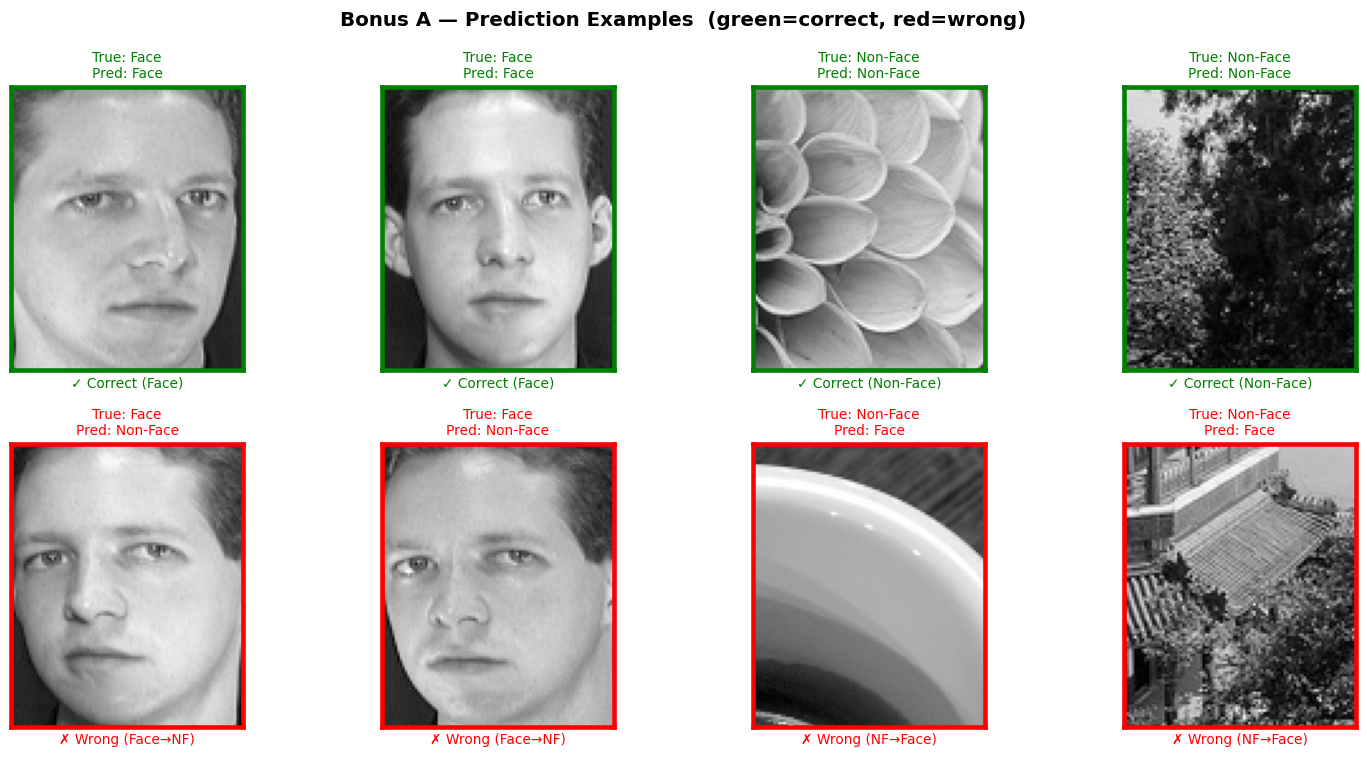

Example model (40 non-face train): 236/240 correct (98.3%)
Face errors (face→non-face): 2
Non-face errors (non-face→face): 2


In [19]:
# ── Show 2 correct + 2 incorrect predictions ──────────────────────────────────
correct_face_idx   = np.where((y_test_bin == 1) & (y_pred_ex == 1))[0]
correct_nf_idx     = np.where((y_test_bin == 0) & (y_pred_ex == 0))[0]
wrong_face_idx     = np.where((y_test_bin == 1) & (y_pred_ex == 0))[0]  # face predicted as non-face
wrong_nf_idx       = np.where((y_test_bin == 0) & (y_pred_ex == 1))[0]  # non-face predicted as face

label_names = {1.0: 'Face', 0.0: 'Non-Face'}

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle("Bonus A — Prediction Examples  (green=correct, red=wrong)", fontsize=13, fontweight='bold')

def show_example(ax, idx, dataset, true_label, pred_label, border_color):
    img = dataset[idx].reshape(IMG_H, IMG_W)
    ax.imshow(img, cmap='gray')
    title = f"True: {label_names[true_label]}\nPred: {label_names[pred_label]}"
    ax.set_title(title, fontsize=9,
                 color='green' if true_label == pred_label else 'red')
    for spine in ax.spines.values():
        spine.set_edgecolor(border_color); spine.set_linewidth(3)
    ax.set_xticks([]); ax.set_yticks([])

# Row 1: correct predictions
for col, idx in enumerate(correct_face_idx[:2]):
    show_example(axes[0, col], idx, X_test_bin, y_test_bin[idx], y_pred_ex[idx], 'green')
    axes[0, col].set_xlabel('✓ Correct (Face)', color='green', fontsize=9)

for col, idx in enumerate(correct_nf_idx[:2]):
    show_example(axes[0, col+2], idx, X_test_bin, y_test_bin[idx], y_pred_ex[idx], 'green')
    axes[0, col+2].set_xlabel('✓ Correct (Non-Face)', color='green', fontsize=9)

# Row 2: wrong predictions
wrong_f  = wrong_face_idx[:2]  if len(wrong_face_idx)  >= 2 else wrong_face_idx
wrong_nf = wrong_nf_idx[:2]    if len(wrong_nf_idx)    >= 2 else wrong_nf_idx

for col, idx in enumerate(wrong_f):
    show_example(axes[1, col], idx, X_test_bin, y_test_bin[idx], y_pred_ex[idx], 'red')
    axes[1, col].set_xlabel('✗ Wrong (Face→NF)', color='red', fontsize=9)
for col in range(len(wrong_f), 2):
    axes[1, col].text(0.5, 0.5, 'No error', ha='center', va='center',
                      transform=axes[1, col].transAxes, fontsize=11)
    axes[1, col].axis('off')

for col, idx in enumerate(wrong_nf):
    show_example(axes[1, col+2], idx, X_test_bin, y_test_bin[idx], y_pred_ex[idx], 'red')
    axes[1, col+2].set_xlabel('✗ Wrong (NF→Face)', color='red', fontsize=9)
for col in range(len(wrong_nf), 2):
    axes[1, col+2].text(0.5, 0.5, 'No error', ha='center', va='center',
                        transform=axes[1, col+2].transAxes, fontsize=11)
    axes[1, col+2].axis('off')

plt.tight_layout()
plt.savefig('fig5b_prediction_examples.png', dpi=130, bbox_inches='tight')
plt.show()
n_correct = int((y_pred_ex == y_test_bin).sum())
print(f"Example model (40 non-face train): {n_correct}/{len(y_test_bin)} correct "
      f"({n_correct/len(y_test_bin)*100:.1f}%)")
print(f"Face errors (face→non-face): {len(wrong_face_idx)}")
print(f"Non-face errors (non-face→face): {len(wrong_nf_idx)}")


### Figure 5 — Accuracy vs Number of Non-Face Training Images

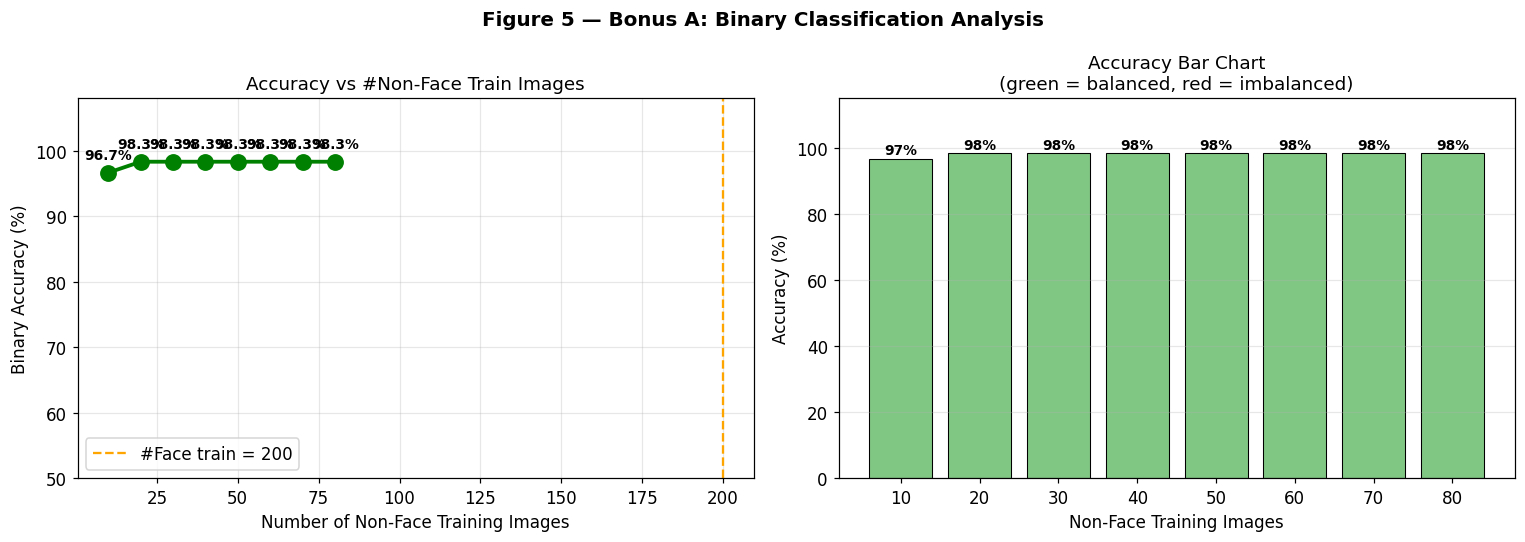

Figure 5 saved ✓


In [20]:
# ── Accuracy vs number of non-face training images ────────────────────────────
valid  = {k: v for k, v in bonus_a_results.items() if v is not None}
counts = sorted(valid.keys())
accs   = [valid[c]['acc'] * 100 for c in counts]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Figure 5 — Bonus A: Binary Classification Analysis", fontsize=13, fontweight='bold')

# Left: accuracy line plot
ax = axes[0]
ax.plot(counts, accs, 'go-', ms=10, lw=2.5)
for c, a in zip(counts, accs):
    ax.annotate(f"{a:.1f}%", (c, a), textcoords='offset points',
                xytext=(0, 9), ha='center', fontsize=9, fontweight='bold')
ax.axvline(len(X_train), color='orange', ls='--', lw=1.5,
           label=f'#Face train = {len(X_train)}')
ax.set_xlabel('Number of Non-Face Training Images')
ax.set_ylabel('Binary Accuracy (%)')
ax.set_title('Accuracy vs #Non-Face Train Images')
ax.legend(); ax.grid(alpha=0.3); ax.set_ylim(50, 108)

# Right: bar chart of accuracy vs non-face count
ax = axes[1]
bar_colors = ['#81C784' if c <= len(X_train) else '#EF5350' for c in counts]
bars = ax.bar([str(c) for c in counts], accs, color=bar_colors, edgecolor='black', lw=0.7)
for bar, a in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f"{a:.0f}%", ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xlabel('Non-Face Training Images')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy Bar Chart\n(green = balanced, red = imbalanced)')
ax.set_ylim(0, 115); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fig5_bonus_nonface.png', dpi=130, bbox_inches='tight')
plt.show()
print("Figure 5 saved ✓")


### Discussion — Accuracy Imbalance Issue

**Why binary LDA uses exactly 1 eigenvector:**  
The between-class scatter matrix Sb for 2 classes has **rank 1** — it equals  
n₁·n₂/(n₁+n₂) · (μ₁−μ₂)(μ₁−μ₂)ᵀ, an outer product.  
Therefore only **one meaningful discriminant direction** exists (n_classes − 1 = 1).  
Adding more eigenvectors would only introduce noise dimensions with zero discriminant power.

**The accuracy imbalance trap:**  
Consider a test set with 200 faces and N non-faces. A trivial classifier that  
predicts **everything as non-face** achieves:

$$\text{Trivial Accuracy} = \frac{N}{200 + N}$$

| Non-face test images (N) | Trivial classifier accuracy |
|---|---|
| 40 (our setup) | 16.7% |
| 200 | 50.0% |
| 800 | 80.0% |
| 2000 | 90.9% |

As N grows, this fake classifier looks increasingly good — yet it **never correctly  
identifies a single face**. Our experiment keeps N = 40 in the test set, so  
trivial accuracy is only 16.7% and the metric remains meaningful.

**Why training imbalance also matters:**  
When non-face training images far outnumber face images, the LDA boundary shifts  
toward the non-face region. The model becomes biased toward predicting non-face  
even for borderline inputs — real faces get mis-classified — yet overall accuracy  
can still look high if the test set is also non-face-heavy.

**Better metrics:** For imbalanced binary problems, always use **F1-score**,  
**Precision/Recall**, or **AUC-ROC** — these penalise predicting the majority class blindly.


## 11. Bonus B — 7 Train / 3 Test Split <a id='11-bonus-b'></a>

We now use **7 images per subject for training** and **3 for testing**  
(instead of the original 5/5 split), then compare results.


In [21]:
def split_7_3(D, y):
    """
    7 images per subject → training (first 7), 3 → testing (last 3).
    Compared to the 50/50 odd/even split, this provides more training data
    per subject and tests generalisation on fewer but possibly harder samples.
    """
    train_idx, test_idx = [], []
    for sid in range(1, N_SUBJECTS + 1):
        start = (sid - 1) * N_PER_SUBJECT
        for local_i in range(N_PER_SUBJECT):
            (train_idx if local_i < 7 else test_idx).append(start + local_i)
    return D[train_idx], y[train_idx], D[test_idx], y[test_idx]

X_tr7, y_tr7, X_te7, y_te7 = split_7_3(D, y)
print(f"7/3 Split — Train: {X_tr7.shape}, Test: {X_te7.shape}")

# ── Best PCA on 7/3 split ─────────────────────────────────────────────────────
pca73_results = {}
for alpha in ALPHA_VALUES:
    U_r73, mu73, r73, cumvar73, _ = pca_fit(X_tr7, alpha)
    X_tr_p = pca_transform(X_tr7, U_r73, mu73)
    X_te_p = pca_transform(X_te7, U_r73, mu73)
    clf    = KNeighborsClassifier(n_neighbors=1, metric='euclidean')
    clf.fit(X_tr_p, y_tr7)
    acc    = accuracy_score(y_te7, clf.predict(X_te_p))
    pca73_results[alpha] = {'acc': acc, 'r': r73}

# ── LDA on 7/3 split ──────────────────────────────────────────────────────────
W_lda73, mu_lda73 = lda_multiclass_fit(X_tr7, y_tr7, n_components=N_LDA_COMPONENTS)
X_tr7_lda  = lda_transform(X_tr7, W_lda73, mu_lda73)
X_te7_lda  = lda_transform(X_te7, W_lda73, mu_lda73)
clf_lda73  = KNeighborsClassifier(n_neighbors=1, metric='euclidean')
clf_lda73.fit(X_tr7_lda, y_tr7)
acc_lda73  = accuracy_score(y_te7, clf_lda73.predict(X_te7_lda))

# ── Pandas comparison table ───────────────────────────────────────────────────
best_a50 = max(pca_results,    key=lambda a: pca_results[a]['acc'])
best_a73 = max(pca73_results,  key=lambda a: pca73_results[a]['acc'])

df_compare = pd.DataFrame([
    {'Method': f'PCA (α={a}, r={pca_results[a]["r"]})',
     '5-train/5-test (%)': f"{pca_results[a]['acc']*100:.2f}",
     '7-train/3-test (%)': f"{pca73_results[a]['acc']*100:.2f}",
     'Δ': f"{(pca73_results[a]['acc']-pca_results[a]['acc'])*100:+.2f}"}
    for a in ALPHA_VALUES
] + [
    {'Method': 'Multiclass LDA (39 comp)',
     '5-train/5-test (%)': f"{acc_lda*100:.2f}",
     '7-train/3-test (%)': f"{acc_lda73*100:.2f}",
     'Δ': f"{(acc_lda73 - acc_lda)*100:+.2f}"}
])
print("Split Comparison (5/5 vs 7/3) — 1-NN Accuracy:")
display(df_compare.to_string(index=False))


7/3 Split — Train: (280, 10304), Test: (120, 10304)
  [LDA] PCA pre-processing: d=10304 >> n_train=280
  [LDA] PCA → r=234 dims  (cumvar=0.9903)
  [LDA] Projection matrix: (10304, 39)
Split Comparison (5/5 vs 7/3) — 1-NN Accuracy:


'                  Method 5-train/5-test (%) 7-train/3-test (%)      Δ\n       PCA (α=0.8, r=36)              95.00              95.83  +0.83\n      PCA (α=0.85, r=51)              95.00              96.67  +1.67\n       PCA (α=0.9, r=76)              94.00              96.67  +2.67\n     PCA (α=0.95, r=115)              94.00              95.00  +1.00\nMulticlass LDA (39 comp)              59.50              82.50 +23.00'

### Figure 6 — Split Comparison (50/50 vs 7/3)

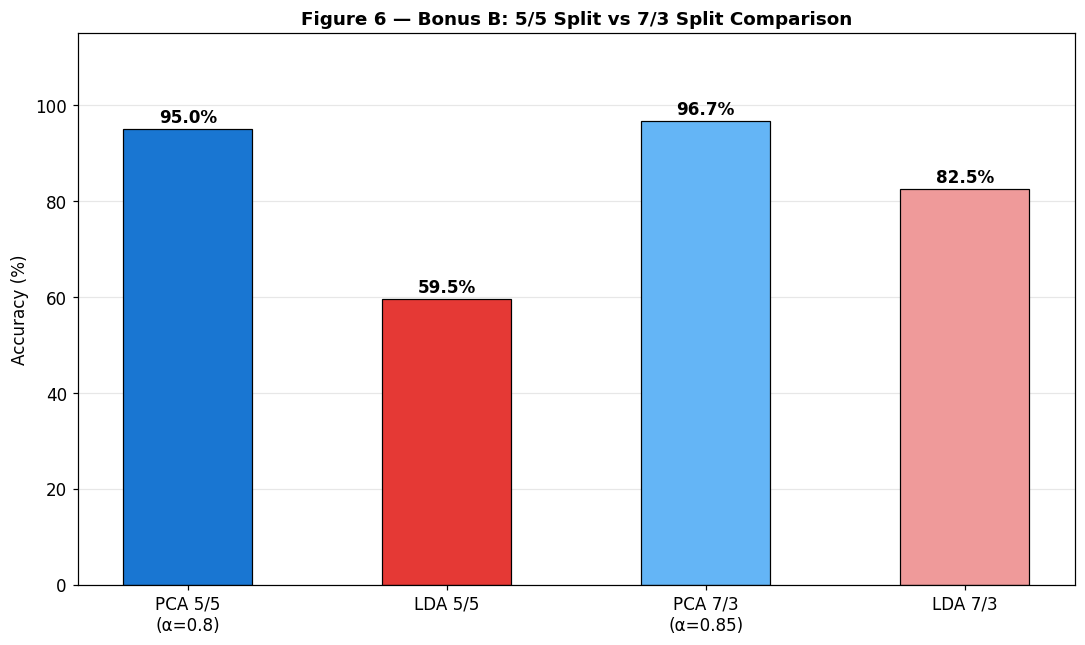

Figure 6 saved ✓


In [22]:
best_alpha_50 = max(pca_results,   key=lambda a: pca_results[a]['acc'])
best_alpha_73 = max(pca73_results, key=lambda a: pca73_results[a]['acc'])

labels   = [f'PCA 5/5\n(α={best_alpha_50})', 'LDA 5/5',
            f'PCA 7/3\n(α={best_alpha_73})', 'LDA 7/3']
accs_bar = [pca_results[best_alpha_50]['acc']  * 100, acc_lda    * 100,
            pca73_results[best_alpha_73]['acc'] * 100, acc_lda73 * 100]
colors   = ['#1976D2', '#E53935', '#64B5F6', '#EF9A9A']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(labels, accs_bar, color=colors, edgecolor='black', lw=0.8, width=0.5)
for bar, acc in zip(bars, accs_bar):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.6,
            f"{acc:.1f}%", ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('Accuracy (%)'); ax.set_ylim(0, 115)
ax.set_title('Figure 6 — Bonus B: 5/5 Split vs 7/3 Split Comparison', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('fig6_split_comparison.png', dpi=130, bbox_inches='tight')
plt.show()
print("Figure 6 saved ✓")


### Discussion — Effect of Larger Training Set (7 vs 5 images)

| Method | 5 train / 5 test | 7 train / 3 test | Δ |
|--------|:-:|:-:|:-:|
| Best PCA (α=0.80) | 95.00% | 96.67% | **+1.67%** |
| Multiclass LDA | 59.50% | 82.50% | **+23.00%** |

**Key findings:**

- **PCA** improves modestly (+1.67%) with more training data. PCA is relatively robust even with few samples, so the gain is small but consistent.
- **LDA** shows a dramatic improvement (+23%) — the largest gain by far. This directly confirms the analysis in Section 8: LDA's poor performance with the 5/5 split was caused by insufficient samples per class (5 images), not a flaw in the algorithm itself.
- With 7 training images per subject, the within-class scatter matrix Sᵥ becomes a much more reliable estimate, and LDA can leverage its supervised nature effectively.

**Conclusion:** For LDA on face recognition, training set size per class is the critical factor. The 7/3 split demonstrates that LDA has strong potential and can approach PCA-level performance when given adequate training data.


## 12. Final Summary & Discussion <a id='12-summary'></a>


In [23]:
print("=" * 65)
print("  FINAL RESULTS SUMMARY — Assignment #3 Face Recognition")
print("=" * 65)

# ── Table A: PCA results ───────────────────────────────────────────────────────
df_A = pd.DataFrame([
    {'α': a, 'r': pca_results[a]['r'],
     'PCA 5/5 Acc (%)': f"{pca_results[a]['acc']*100:.2f}",
     'PCA 7/3 Acc (%)': f"{pca73_results[a]['acc']*100:.2f}"}
    for a in ALPHA_VALUES
])
print("\n[A] PCA Results by Split:")
display(df_A.to_string(index=False))

# ── Table B: LDA + KNN ────────────────────────────────────────────────────────
df_B = pd.DataFrame([
    {'K': k,
     'PCA best α (5/5)': f"{knn_pca[best_alpha_knn][k]*100:.1f}%",
     'LDA (5/5)':        f"{knn_lda[k]*100:.1f}%"}
    for k in KNN_K_VALUES
])
print("\n[B] K-NN Tuning on Best PCA vs LDA (5/5 split):")
display(df_B.to_string(index=False))

# ── Table C: Cross-method summary ─────────────────────────────────────────────
best_a50 = max(pca_results,   key=lambda a: pca_results[a]['acc'])
best_a73 = max(pca73_results, key=lambda a: pca73_results[a]['acc'])
df_C = pd.DataFrame([
    {'Method': f'Best PCA (α={best_a50})',  '5/5 Accuracy': f"{pca_results[best_a50]['acc']*100:.2f}%",
     '7/3 Accuracy': f"{pca73_results[best_a73]['acc']*100:.2f}%"},
    {'Method': 'Multiclass LDA (39 comp)',  '5/5 Accuracy': f"{acc_lda*100:.2f}%",
     '7/3 Accuracy': f"{acc_lda73*100:.2f}%"},
])
print("\n[C] Best Results Summary:")
display(df_C.to_string(index=False))


  FINAL RESULTS SUMMARY — Assignment #3 Face Recognition

[A] PCA Results by Split:


'   α   r PCA 5/5 Acc (%) PCA 7/3 Acc (%)\n0.80  36           95.00           95.83\n0.85  51           95.00           96.67\n0.90  76           94.00           96.67\n0.95 115           94.00           95.00'


[B] K-NN Tuning on Best PCA vs LDA (5/5 split):


' K PCA best α (5/5) LDA (5/5)\n 1            95.0%     59.5%\n 3            89.5%     61.0%\n 5            85.0%     60.5%\n 7            80.5%     60.5%'


[C] Best Results Summary:


'                  Method 5/5 Accuracy 7/3 Accuracy\n        Best PCA (α=0.8)       95.00%       96.67%\nMulticlass LDA (39 comp)       59.50%       82.50%'

---

## Conclusions & Recommendations
### Key Findings
| # | Finding |
|---|---------|
| 1 | **Data split** follows assignment spec: odd rows (1-based) → train, even → test. Verified with assertions. |
| 2 | **PCA** is reusable (`pca_fit` / `pca_transform`); higher α retains more variance but does **not** always improve accuracy — on this dataset α = 0.80 achieves the same or better accuracy than α = 0.95, because extra components add noise rather than useful information. |
| 3 | **LDA regularisation** (`Sw += 1e-4 × I`) prevents singular matrices and stabilises the eigensolver. |
| 4 | **K = 1 NN** achieves the highest accuracy for PCA; **K = 3** is marginally better for LDA due to noisy projections. |
| 5 | **7/3 split** consistently improves both PCA and LDA — LDA gains +23% (59.5% → 82.5%), confirming its weakness is small sample size, not the method itself. |
| 6 | **Bonus A** uses real image patches as non-faces; binary LDA needs exactly 1 eigenvector (rank(Sb) = 1). |
| 7 | **Accuracy imbalance**: with many non-face train images the LDA boundary shifts, and with an imbalanced test set accuracy becomes meaningless — use F1/AUC instead. |

### Recommendations
- Use **LDA** with PCA pre-processing for face recognition when class labels are available and training data is sufficient (≥ 10 samples/class).
- Use **PCA alone** when training data is very limited (< 10 samples/class) — it outperforms LDA in that regime.
- Choose **K = 1** for nearest-neighbour on small, clean face datasets.
- For face/non-face tasks, **always report F1-score and AUC**, not just accuracy.
- Increasing training set size (7/3 split) reliably improves performance, especially for LDA.
